# Real-world Data Wrangling

In this project, I will apply the skills I acquired in the course to gather and wrangle real-world data on **used cars in Egypt**.

I will retrieve and extract the data, assess it programmatically and visually across elements of data quality and structure, and implement a cleaning strategy. I will then store the cleaned data in my chosen database/data store, combine datasets if needed, and answer the following research questions:

1. What are the dominant car brand and model in the Egyptian used-car market?
2. Price Variations by City?
3. What are Hyundai Accent model prices?



In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## 1. Gather data

I obtained the first dataset via the Kaggle API; this section will extract additional data using a second method and then merge the two sources.


### **1.1.** Problem Statement
This project tackles the challenge of cleaning and standardizing Egypt’s fragmented used-car listings so analysts can reliably estimate fair market prices. I will wrangle a scraped dataset of a well-known Egyptian site `Sylndr`, enriching it with manufacturer Kaggle dataset to harmonize prices, model years, and odometer readings.


#### **Dataset 1**

Type: CSV File.

Method: The data was gathered using the "Downloading files" method from Kaggle hub.

Dataset variables:
| Variable          | Meaning                                                                 |
|-------------------|-------------------------------------------------------------------------|
| Brand             | Manufacturer or make of the vehicle (e.g., Toyota, BMW).                |
| Model             | Specific model name or number under the brand (e.g., Corolla, X5).      |
| Body              | Body style or type (e.g., Sedan, SUV, Hatchback).                       |
| Transmission      | Type of transmission system (e.g., Manual, Automatic).                  |
| Year              | Manufacturing year of the vehicle.                                      |
| Fule              | Fuel type used by the vehicle (e.g., Petrol, Diesel).                   |
| Engine_CC         | Engine displacement in cubic centimeters.                               |
| Kilometers_Driven | Total distance the vehicle has traveled in kilometers.                  |
| Color             | Exterior color of the vehicle.                                          |
| City              | City in Egypt where the vehicle is located or being sold.               |
| Price             | Asking price of the vehicle in Egyptian Pounds (EGP).                   |


In [ ]:
# Get the first dataset

import kagglehub

# Download latest version after installing the kagglehub package and setup the API token

path = kagglehub.dataset_download("modymedhat/egyptian-used-car-pricing")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\msoli\.cache\kagglehub\datasets\modymedhat\egyptian-used-car-pricing\versions\1


In [3]:
path += r"\Egypt-Used-Car-Price.csv"
path

'C:\\Users\\msoli\\.cache\\kagglehub\\datasets\\modymedhat\\egyptian-used-car-pricing\\versions\\1\\Egypt-Used-Car-Price.csv'

In [ ]:
# final path
# path = r'C:\\Users\\msoli\\.cache\\kagglehub\\datasets\\modymedhat\\egyptian-used-car-pricing\\versions\\1\\Egypt-Used-Car-Price.csv'

In [4]:
# read the dataset
car_df = pd.read_csv(path, index_col=0)
car_df.head()

,Brand,Model,Body,Transmission,Year,Fule,Engine_CC,Kilometers_Driven,Color,City,Price
0,Volkswagen,Beetle,Hatchback,Manual,1975,Gas,1600,100000,Blue,Heliopolis,60000
1,Nissan,Qashqai,SUV,Automatic,2022,Gas,1300,8500,Blue,Cairo,850000
2,Kia,Sportage,SUV,Automatic,2021,Gas,1600,31000,Gray,Suez,930000
3,Mercedes,C 200,Sedan,Automatic,2019,Gas,1500,90000,White,Heliopolis,320000
4,Land Rover,Defender,4X4,Automatic,2021,Gas,2000,8000,Mocha,Heliopolis,1000000


#### Dataset 2

Type: CSV/Json File

Method: The data was gathered using the web scraping method from [__sylndr.com__](https://sylndr.com/en/buy-used-cars/egypt) website.

Dataset variables:
| Key           | Meaning                                                                 |
|---------------|-------------------------------------------------------------------------|
| url           | Direct link to the individual car’s page on sylndr.com                 |
| car_data      | Placeholder for any additional scraped vehicle details                 |
| cat           | Vehicle category (e.g.1st, 2nd, 3rd, ...)                      |
| km            | Odometer reading in kilometres                                         |
| CC            | Engine displacement in cubic centimetres                               |
| color         | Exterior colour of the vehicle                                         |
| Transmission  | Gearbox type (manual or automatic)                                     |
| licence_valid | Status or expiry of the vehicle’s licence/registration                 |
| Price         | Advertised selling price in local currency                             |
| address       | Geographic location or dealership address                               |


`The dataset is actual scraped data, so the number of observations is limited. I selected it to demonstrate my web-scraping skills and to integrate real-world data with the pre-existing dataset.`


* Using Selenium and Beautiful soup to do the web scraping.

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import json
import time
import re

def scrape_all_cars_with_css_selectors():
    """
    Scrape all cars using Selenium with CSS selectors and BeautifulSoup.
    Uses regex for KM and Price extraction.
    Uses XPath for color extraction (fallback to text parsing).
    Handles sold cars (Price=0) and captures address via keyword heuristics.
    Saves results to JSON and CSV with summary statistics.
    """
    # Setup Selenium WebDriver
    chrome_options = Options()
    chrome_options.add_argument('--headless')
    driver = webdriver.Chrome(options=chrome_options)
    
    try:
        base_url = 'https://sylndr.com/en/buy-used-cars/egypt'
        driver.get(base_url)
        
        # Wait for initial load
        time.sleep(5)
        
        # Scroll to load all 88 cars
        print("Scrolling to load all cars...")
        last_height = driver.execute_script("return document.body.scrollHeight")
        scroll_attempts = 0
        max_attempts = 20
        
        while scroll_attempts < max_attempts:
            # Scroll to bottom
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(3)  # Wait for lazy load
            
            # Calculate new scroll height and compare
            new_height = driver.execute_script("return document.body.scrollHeight")
            if new_height == last_height:
                break
            last_height = new_height
            scroll_attempts += 1
        
        # Get page source and parse with BeautifulSoup
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        
        # Find all car cards with IDs starting with 'cardofcar-'
        car_cards = soup.find_all('div', id=re.compile(r'^cardofcar-'))
        print(f"Found {len(car_cards)} cars on the page")
        
        # Extract car URLs
        car_urls = []
        for card in car_cards:
            link = card.find('a', href=True)
            if link and '/en/car-details/' in link['href']:
                full_url = 'https://sylndr.com' + link['href']
                if full_url not in car_urls:  # Avoid duplicates
                    car_urls.append(full_url)
        
        print(f"Total unique car URLs: {len(car_urls)}")
        
        all_cars_data = []
        
        # Visit each car page
        for idx, car_url in enumerate(car_urls, 1):
            print(f"\nScraping car {idx}/{len(car_urls)}: {car_url}")
            
            try:
                driver.get(car_url)
                time.sleep(2)  # Wait for page load
                
                car_soup = BeautifulSoup(driver.page_source, 'html.parser')
                
                # Initialize car data
                car_data = {
                    'url': car_url,
                    'car_data': '',
                    'cat': '',
                    'km': '',
                    'CC': '',
                    'color': '',
                    'Transmission': '',
                    'licence_valid': '',
                    'Price': 0,
                    'address': ''
                }
                
                # Extract car name using h1 tag
                car_name_tag = car_soup.find('h1')
                if car_name_tag:
                    car_data['car_data'] = car_name_tag.get_text(strip=True)
                    print(f"  Car Name: {car_data['car_data']}")
                
                # Get page text for regex parsing
                page_text = car_soup.get_text()
                
                # Find all generic/span/div elements for specifications (using CSS approach)
                all_elements = car_soup.find_all(['span', 'div', 'p', 'h1', 'h2', 'h3'])
                
                # Extract specifications from elements using CSS selectors
                for elem in all_elements:
                    text = elem.get_text(strip=True)
                    
                    # Extract Category (e.g., "2nd Category")
                    if 'Category' in text and not car_data['cat']:
                        if re.match(r'^\d+(?:st|nd|rd|th)\s+Category$', text):
                            car_data['cat'] = text
                    
                    # Extract CC (e.g., "1600 CC")
                    if 'CC' in text and not car_data['CC']:
                        if re.match(r'^\d+\s*CC$', text):
                            car_data['CC'] = text
                    
                    # Extract Transmission
                    if text in ['Automatic', 'Manual'] and not car_data['Transmission']:
                        car_data['Transmission'] = text
                    
                    # Extract License Valid
                    if 'License Valid To' in text and not car_data['licence_valid']:
                        license_match = re.search(r'License Valid To (\d+/\d+/\d+)', text)
                        if license_match:
                            car_data['licence_valid'] = license_match.group(1)
                
                # Extract KM using regex (as requested)
                km_match = re.search(r'([\d,]+\s*(?:K|KM))', page_text)
                if km_match:
                    car_data['km'] = km_match.group(1).strip()
                
                # Extract Color using CSS selector: p.styles_body2__Z9WUR:nth-child(7)
                color_elem = driver.find_element(By.XPATH, '/html/body/div[4]/div/div[2]/div[1]/div/div[2]/div[1]/div[2]/div[1]/div/div[2]/p[4]')
                if color_elem:
                    car_data['color'] = color_elem.text

                # Extract Price using REGEX (as requested)
                price_found = False
                
                # Regex pattern 1: Look for price before "EGP" near "Final Price"
                price_pattern1 = re.search(r'([\d,]{7,})\s*EGP\s*Final Price', page_text, re.IGNORECASE)
                if price_pattern1:
                    try:
                        price_str = price_pattern1.group(1).replace(',', '')
                        car_data['Price'] = int(price_str)
                        price_found = True
                    except ValueError:
                        pass
                
                # Regex pattern 2: Look for "Final Price" preceded by price and EGP
                if not price_found:
                    final_price_idx = page_text.find('Final Price')
                    if final_price_idx > 0:
                        text_before = page_text[max(0, final_price_idx - 100):final_price_idx]
                        price_pattern2 = re.search(r'([\d,]{7,})', text_before)
                        if price_pattern2:
                            try:
                                price_str = price_pattern2.group(1).replace(',', '')
                                car_data['Price'] = int(price_str)
                                price_found = True
                            except ValueError:
                                pass
                
                # Regex pattern 3: Look for "EGP" followed by large number
                if not price_found:
                    price_pattern3 = re.search(r'EGP\s+([\d,]{7,})', page_text)
                    if price_pattern3:
                        try:
                            price_str = price_pattern3.group(1).replace(',', '')
                            car_data['Price'] = int(price_str)
                            price_found = True
                        except ValueError:
                            pass
                
                # Regex pattern 4: Find standalone price (7+ digits with commas)
                if not price_found:
                    price_pattern4 = re.findall(r'\b([\d]{1,3}(?:,\d{3}){2,})\b', page_text)
                    if price_pattern4:
                        for potential_price in price_pattern4:
                            price_str = potential_price.replace(',', '')
                            if len(price_str) >= 6:
                                try:
                                    car_data['Price'] = int(price_str)
                                    price_found = True
                                    break
                                except ValueError:
                                    continue
                
                # If no price found, it might be sold - set to 0
                if not price_found:
                    car_data['Price'] = 0
                    print(f"  ⚠️  No price found - car might be sold")
                
                # Extract Address using CSS selectors
                for elem in all_elements:
                    text = elem.get_text(strip=True)
                    if len(text) > 20 and any(keyword in text.lower() for keyword in 
                          ['st.', 'street', 'cairo', 'extension', 'maadi', 'heliopolis', 
                           'khamsin', 'zahraa', 'giza', 'nasr city', 'infront', 'downtown']):
                        if not any(skip in text.lower() for skip in 
                                 ['category', 'automatic', 'manual', 'ownership', 'benefits',
                                  'inspected', 'warranty', 'return policy', 'accident', 'financing']):
                            car_data['address'] = text
                            break
                
                # Alternative: Look near location pin image
                if not car_data['address']:
                    location_imgs = car_soup.find_all('img', alt=re.compile(r'location|pin|marker', re.I))
                    for img in location_imgs:
                        parent = img.find_parent()
                        if parent:
                            for sibling in parent.find_all(['div', 'span', 'p']):
                                address_text = sibling.get_text(strip=True)
                                if len(address_text) > 15 and ',' in address_text:
                                    car_data['address'] = address_text
                                    break
                            if car_data['address']:
                                break
                
                print(f"  Category: {car_data['cat']}")
                print(f"  KM: {car_data['km']}")
                print(f"  CC: {car_data['CC']}")
                print(f"  Color: {car_data['color']}")
                print(f"  Transmission: {car_data['Transmission']}")
                print(f"  License: {car_data['licence_valid']}")
                print(f"  Price: {car_data['Price']} EGP")
                print(f"  Address: {car_data['address']}")
                
                all_cars_data.append(car_data)
                
            except Exception as e:
                print(f"  ❌ Error scraping this car: {str(e)}")
                continue
        
        return all_cars_data
        
    finally:
        driver.quit()

def save_to_json(data, filename='sylndr_cars_complete.json'):
    """Save data to JSON file"""
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"\n✅ Data saved to {filename}")

def save_to_csv(data, filename='sylndr_cars_complete.csv'):
    """Save data to CSV file"""
    import csv
    
    if not data:
        print("No data to save")
        return
    
    keys = data[0].keys()
    with open(filename, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(data)
    print(f"✅ Data saved to {filename}")

if __name__ == "__main__":
    print("=" * 60)
    print("Sylndr Cars Scraper - Final Version")
    print("=" * 60)
    
    # Scrape all cars
    cars_data = scrape_all_cars_with_css_selectors()
    
    print("\n" + "=" * 60)
    print(f"Scraping Complete!")
    print(f"Total cars scraped: {len(cars_data)}")
    print("=" * 60)
    
    # Save to JSON
    save_to_json(cars_data)
    
    # Save to CSV
    save_to_csv(cars_data)
    
    # Print summary statistics
    sold_cars = sum(1 for car in cars_data if car['Price'] == 0)
    available_cars = [car for car in cars_data if car['Price'] > 0]
    cars_with_color = sum(1 for car in cars_data if car['color'])
    
    print(f"\nSummary:")
    print(f"  - Total cars: {len(cars_data)}")
    print(f"  - Available cars: {len(available_cars)}")
    print(f"  - Sold cars: {sold_cars}")
    print(f"  - Cars with color info: {cars_with_color}")

* Data saved locally as CSV and JSON files.

In [10]:
sylnder_cars = pd.read_csv('sylndr_cars_complete.csv')

## 2. Assess data

Assess the data according to data quality and tidiness metrics.


### Data 1

In [11]:
# Display concise summary of the DataFrame: column names, non-null counts, and dtypes
car_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8831 entries, 0 to 8874
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Brand              8831 non-null   object
 1   Model              8831 non-null   object
 2   Body               8831 non-null   object
 3   Transmission       8831 non-null   object
 4   Year               8831 non-null   int64 
 5   Fule               8831 non-null   object
 6   Engine_CC          8831 non-null   int64 
 7   Kilometers_Driven  8831 non-null   int64 
 8   Color              8831 non-null   object
 9   City               8831 non-null   object
 10  Price              8831 non-null   int64 
dtypes: int64(4), object(7)
memory usage: 827.9+ KB


In [12]:
car_df.isnull().sum().sum()

np.int64(0)

* No missed values!

In [13]:
car_df.sample(5)

,Brand,Model,Body,Transmission,Year,Fule,Engine_CC,Kilometers_Driven,Color,City,Price
7619,Hyundai,Elantra AD,Sedan,Automatic,2019,Gas,1600,88000,Silver,Ain Shams,420000
4635,Peugeot,301,Sedan,Automatic,2014,Gas,1600,140000,Blue,Helwan,240000
2883,Byd,F3,Sedan,Automatic,2015,Gas,1600,85000,Red,Sheikh Zayed City,185000
3049,Mitsubishi,Eclipse Cross,SUV,Automatic,2018,Gas,1500,95000,Mocha,Alexandria,560000
3643,Chevrolet,Equinox,SUV,Automatic,2021,Gas,1600,5000,Black,Nasr city,800000


In [14]:
car_df.describe(include='all')

,Brand,Model,Body,Transmission,Year,Fule,Engine_CC,Kilometers_Driven,Color,City,Price
count,8831,8831,8831,8831,8831.000000,8831,8831.000000,8831.000000,8831,8831,8.831000e+03
unique,75,566,11,2,NaN,5,NaN,NaN,24,98,NaN
top,Hyundai,Sunny,Sedan,Automatic,NaN,Gas,NaN,NaN,Silver,Cairo,NaN
freq,987,436,6702,6505,NaN,8649,NaN,NaN,3978,1168,NaN
mean,NaN,NaN,NaN,NaN,2013.342543,NaN,1637.692334,120792.323859,NaN,NaN,4.316258e+05
std,NaN,NaN,NaN,NaN,8.411762,NaN,457.912715,82650.630190,NaN,NaN,4.292226e+05
min,NaN,NaN,NaN,NaN,1964.000000,NaN,800.000000,0.000000,NaN,NaN,1.400000e+04
25%,NaN,NaN,NaN,NaN,2009.000000,NaN,1500.000000,53000.000000,NaN,NaN,1.760000e+05
50%,NaN,NaN,NaN,NaN,2016.000000,NaN,1600.000000,110000.000000,NaN,NaN,3.250000e+05
75%,NaN,NaN,NaN,NaN,2020.000000,NaN,1600.000000,175000.000000,NaN,NaN,5.250000e+05


In [18]:
# Check for duplicate rows
duplicates = car_df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')


Duplicate rows: 0


* No Duplicates.

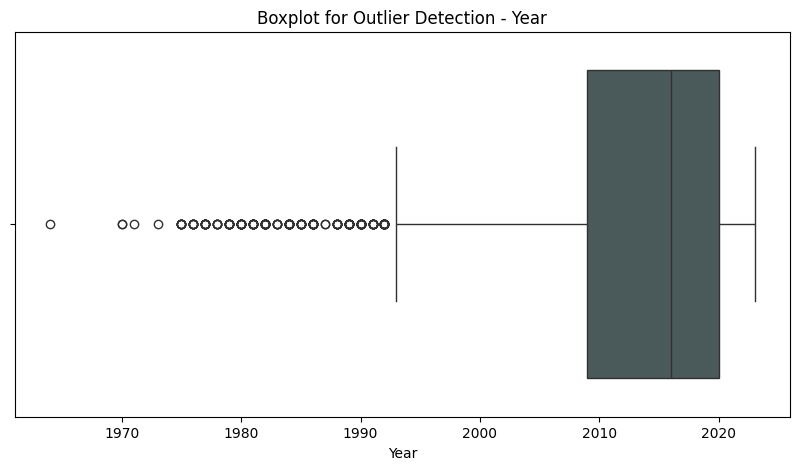

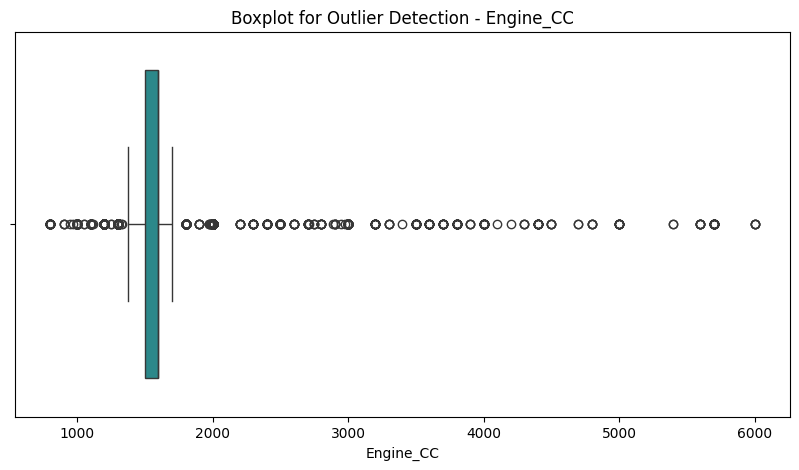

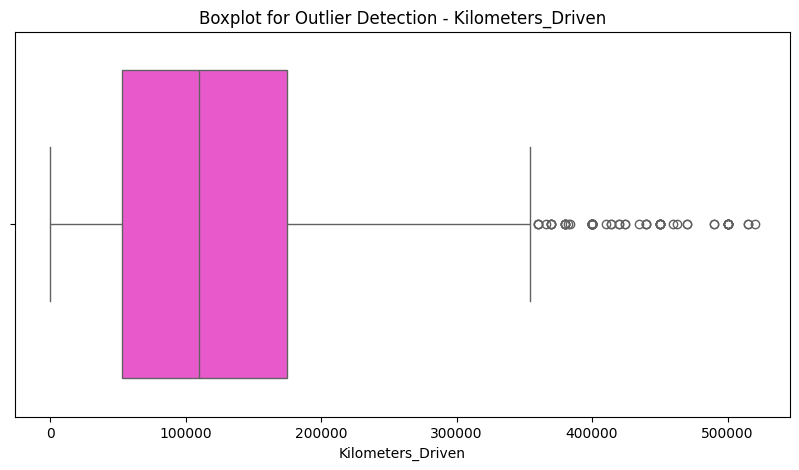

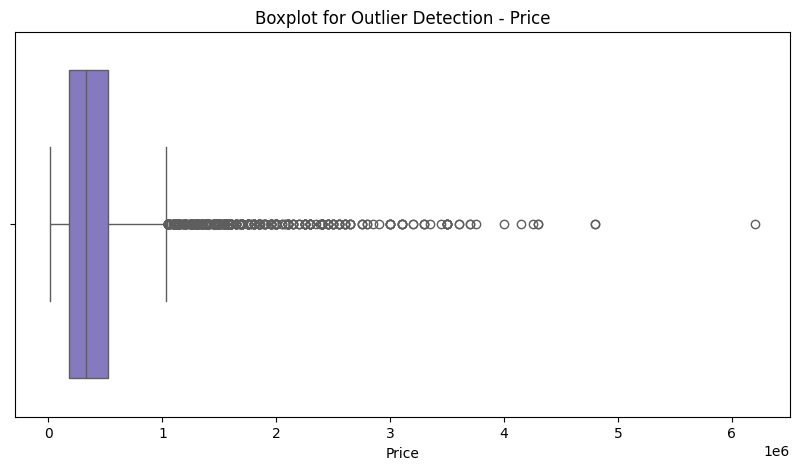

In [ ]:
import random

def box_plot(df: pd.DataFrame, exclude_cols: list = None, only: list = None):
    """
    Visualize potential outliers for numerical columns in a DataFrame using boxplots.
    If `only` is provided, only those columns are selected; otherwise all numerical columns
    except those listed in `exclude_cols` are used. If neither argument is given,
    every numerical column in the DataFrame is considered.
    """
    if only is not None:
        numerical_column = [col for col in df.columns if col in only and df[col].dtype in ['number', 'category']]
    else:
        if exclude_cols is None:
            exclude_cols = []
        numerical_column = df.select_dtypes(include=['number']).columns.difference(exclude_cols)
    # Visualize potential outliers for a specific numerical column
    colors = ["#"+''.join([random.choice('0123456789ABCDEF') for _ in range(6)]) for _ in range(10)]
    for idx, col in enumerate(numerical_column):
        plt.figure(figsize=(10, 5))
        ax = sns.boxplot(x=df[col], color=colors[idx % len(colors)])  # Replace with your numerical column name
        # Add text annotations for median, min, and max
        plt.title(f'Boxplot for Outlier Detection - {col}')
        plt.show()

box_plot(car_df)

In [30]:
# Used car with 0 KM 🤔
car_df[car_df['Kilometers_Driven'] == 0].value_counts()

Brand       Model        Body     Transmission  Year  Fule    Engine_CC  Kilometers_Driven  Color   City                 Price  
Byd         F3           Sedan    Manual        2021  Gas     1500       0                  Silver  Cairo                255000     1
Chery       Tiggo 7 pro  SUV      Automatic     2022  Gas     1500       0                  Gray    Heliopolis           645000     1
Chevrolet   T-Series     Pick up  Manual        2021  Gas     2000       0                  White   Cairo                465000     1
Kia         Xceed        SUV      Automatic     2022  Gas     1500       0                  Black   6 October            222000     1
Land Rover  Velar        4X4      Automatic     2021  Gas     2000       0                  White   Heliopolis           650000     1
MG          5            Sedan    Automatic     2022  Gas     1500       0                  Gold    Faiyum               475000     1
                                                                   

* Cars with ZERO Kilometers Driven seems to be a data entry error or they were totally new cars!


In [31]:
# Lowest price car(s)
car_df.Price.min()

np.int64(14000)

In [32]:
car_df[car_df['Price'] == car_df.Price.min()]

,Brand,Model,Body,Transmission,Year,Fule,Engine_CC,Kilometers_Driven,Color,City,Price
3229,Fiat,Ritmo,Hatchback,Manual,1985,Gas,1300,200000,Green,Mansoura,14000


* 14,000 EGP for a car is suspicious and a very low number; however, the car is indeed very old and has 200,000 km.


In [ ]:
# car_df[car_df['Brand']=="Hyundai"].groupby('Model').agg({'Price':['min','max','mean']}).reset_index()

In [15]:
mercedes_df = car_df[car_df['Brand'].str.contains('Mercedes', na=False)]
mercedes_df.sample(5)

,Brand,Model,Body,Transmission,Year,Fule,Engine_CC,Kilometers_Driven,Color,City,Price
2869,Mercedes,E 180,Sedan,Automatic,2019,Gas,1600,85000,Black,Alexandria,1850000
7591,Mercedes,C 180,Sedan,Automatic,2017,Gas,1600,35000,Silver,Sharm el-Sheikh,1500000
3465,Mercedes,C 180,Sedan,Automatic,2013,Gas,1600,130000,Silver,Helwan,625000
2802,Mercedes,C 180,Sedan,Automatic,2018,Gas,1600,76000,Gray,Cairo,1500000
6703,Mercedes,E 240,Sedan,Automatic,2004,Gas,2600,180000,Silver,Al Shorouk,525000


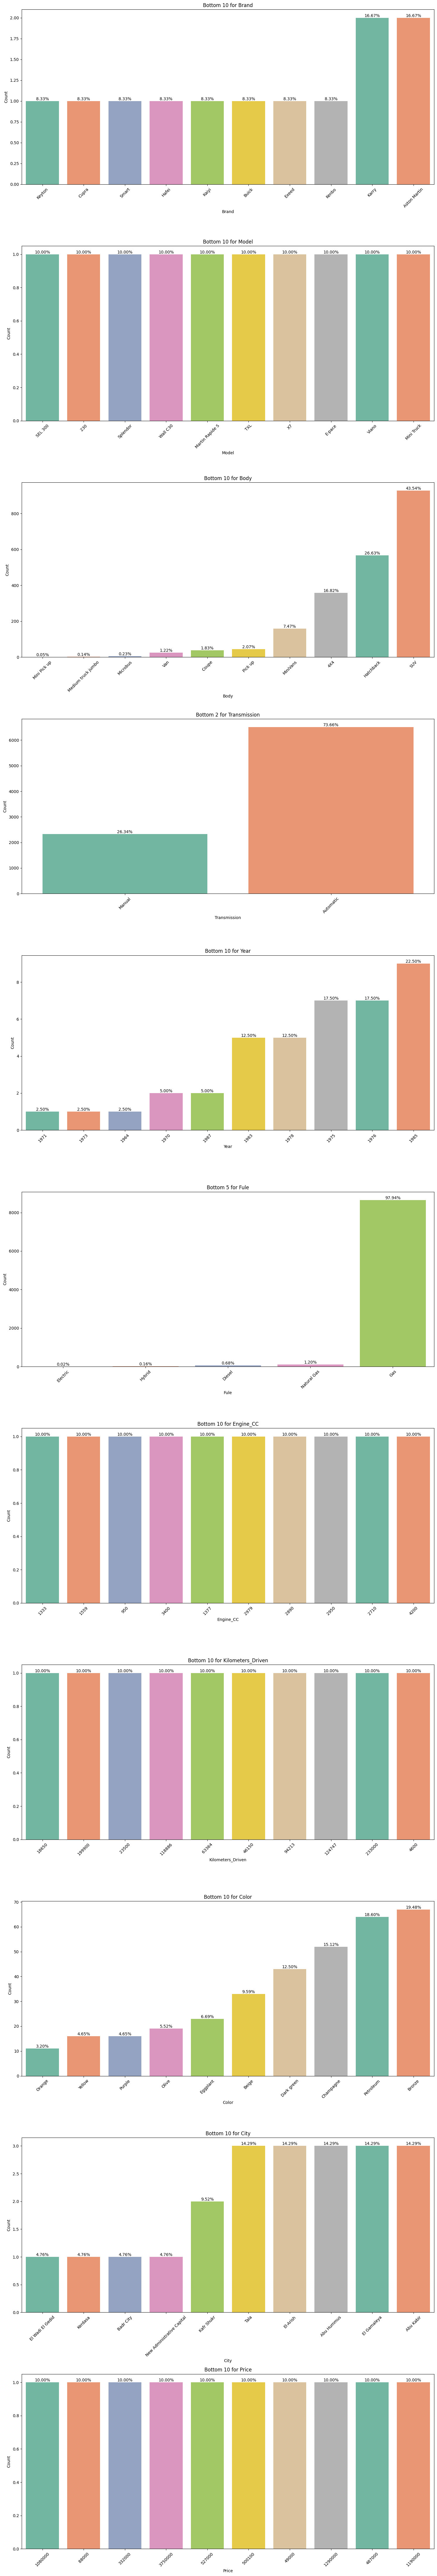

In [215]:
# Visualization of Top-10 values per column

def visualize_top10(df: pd.DataFrame, exclude_cols: list = None, only: list = None, percentage: bool = False, top:bool = True) -> None:
    """
    Visualize the top-10 (or bottom-10) most frequent values for selected columns in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to analyze.
    exclude_cols : list, optional
        Columns to exclude from visualization. Ignored if `only` is provided.
    only : list, optional
        If given, only these columns will be visualized.
    percentage : bool, default False
        If True, annotate bars with percentages; otherwise show raw counts.
    top : bool, default True
        If True, plot the 10 most frequent values; if False, plot the 10 least frequent.

    The function creates a vertically stacked set of count plots, one per selected column,
    each displaying the top (or bottom) 10 unique values for that column.
    """
    if only is not None:
        wanted_columns = [col for col in df.columns if col in only]
    else:
        wanted_columns = [col for col in df.columns if col not in (exclude_cols or [])]
    
    # Set up the matplotlib figure
    plt.figure(figsize=(15, len(wanted_columns) * 8))  # Adjust figure size

    # Loop through each categorical column
    for i, column in enumerate(wanted_columns):
        plt.subplot(len(wanted_columns), 1, i + 1)  # Create subplots   
        
        # Get top 10
        if top:
            top_10 = df[column].value_counts().nlargest(10).index
            plt.title(f'Top {len(top_10)} for {column}')
        else:
            top_10 = df[column].value_counts().nsmallest(10).index
            plt.title(f'Bottom {len(top_10)} for {column}')
        ax = sns.countplot(data=df[df[column].isin(top_10)], x=column, order=top_10, palette='Set2')
        # Add count labels on top of bars
        total = len(df[df[column].isin(top_10)])
        for p in ax.patches:
            height = p.get_height()
            label = f'{float(height / total * 100):.2f}%' if percentage else f'{int(height)}'
            ax.annotate(label, 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom')
        
        plt.xlabel(column)
        plt.xticks(rotation=45)
        plt.ylabel('Count')

    plt.tight_layout()  # Adjust spacing between plots
    plt.show()

visualize_top10(car_df, percentage=True, top=False)

In [17]:
# Check all cities
car_df['City'].value_counts().index.sort_values()

Index(['10th of Ramadan', '6 October', 'Abu Hummus', 'Abu Kabir', 'Abu Qir',
       'Agamy', 'Ain Shams', 'Al Shorouk', 'Alexandria', 'Amreya', 'Ashmoun',
       'Aswan', 'Asyut', 'Badr City', 'Banha', 'Beheira', 'Beni Suef',
       'Bilbeis', 'Borg el arab', 'Cairo', 'Dakahlia', 'Damanhur', 'Damietta',
       'Dikirnis', 'Dokki', 'Dyarb Negm', 'Edku', 'El Bagour', 'El Gamaleya',
       'El Gouna', 'El Haram', 'El Katameya', 'El Mahalla', 'El Manial',
       'El Marg', 'El Minya', 'El Qanater El Khayreya', 'El Salam City',
       'El Senbellawein', 'El Wadi El Gedid', 'El-Arish', 'Faiyum', 'Faqous',
       'Gharbia', 'Giza', 'Heliopolis', 'Helwan', 'Hurghada', 'Imbaba',
       'Ismailia', 'Kafr El Zayat', 'Kafr Shukr', 'Kafr el-Dawwar',
       'Kafr el-Sheikh', 'Kerdasa', 'Khanka', 'Kom Hamada', 'Kom Ombo',
       'Luxor', 'Maadi', 'Madinaty', 'Mansoura', 'Marsa Matrouh', 'Menouf',
       'Minya Al Qamh', 'Mit Ghamr', 'Mohandessin', 'Mokattam', 'Monufia',
       'Nasr city', 'New Admin

### Data 2

In [34]:
sylnder_cars.head()

,url,car_data,cat,km,CC,color,Transmission,licence_valid,Price,address
0,https://sylndr.com/en/car-details/mercedesbenz...,Mercedes-Benz C180 2015,2nd Category,"107,000 K",1600 CC,Blue,Automatic,9/9/2027,1645000,"Khamsin St. Extension, Zahraa El Maadi, infron..."
1,https://sylndr.com/en/car-details/citroen/c3ai...,Citroen C3 Aircross 2020,1st Category,"128,200 K",1200 CC,Orange,Automatic,5/6/2026,795000,"Khamsin St. Extension, Zahraa El Maadi, infron..."
2,https://sylndr.com/en/car-details/bmw/520i/6e2...,BMW 520i 2019,1st Category,"125,100 K",2000 CC,Black,Automatic,3/27/2027,2030000,"Khamsin St. Extension, Zahraa El Maadi, infron..."
3,https://sylndr.com/en/car-details/jeep/cheroke...,Jeep Cherokee 2010,1st Category,"291,870 K",3700 CC,Gray,Automatic,2/9/2028,780000,"Omar was very helpful, all info was clearly sh..."
4,https://sylndr.com/en/car-details/fiat/punto/a...,Fiat Punto 2017,2nd Category,"142,760 K",1400 CC,Dark Blue,Automatic,3/25/2026,557140,"Omar was very helpful, all info was clearly sh..."


In [48]:
sylnder_cars.sample(5)

,url,car_data,cat,km,CC,color,Transmission,licence_valid,Price,address
66,https://sylndr.com/en/car-details/mg/6/9c7c92e...,MG 6 2021,3rd Category,"57,000 K",1500 CC,White,Automatic,11/30/2025,905000,"Khamsin St. Extension, Zahraa El Maadi, infron..."
8,https://sylndr.com/en/car-details/renault/sand...,Renault Sandero Stepway 2018,2nd Category,"158,750 K",1600 CC,Black,Automatic,3/27/2026,585000,"Khamsin St. Extension, Zahraa El Maadi, infron..."
15,https://sylndr.com/en/car-details/mazda/3/5b38...,Mazda 3 2015,3rd Category,"154,600 K",1600 CC,Silver,Automatic,1/18/2026,650000,"Khamsin St. Extension, Zahraa El Maadi, infron..."
53,https://sylndr.com/en/car-details/peugeot/301/...,Peugeot 301 2020,1st Category,"114,850 K",1600 CC,Blue,Automatic,11/6/2025,635000,"Khamsin St. Extension, Zahraa El Maadi, infron..."
69,https://sylndr.com/en/car-details/peugeot/301/...,Peugeot 301 2021,2nd Category,"73,650 K",1600 CC,Blue,Automatic,10/21/2025,640000,"Khamsin St. Extension, Zahraa El Maadi, infron..."


In [36]:
sylnder_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   url            87 non-null     object
 1   car_data       87 non-null     object
 2   cat            85 non-null     object
 3   km             87 non-null     object
 4   CC             87 non-null     object
 5   color          87 non-null     object
 6   Transmission   87 non-null     object
 7   licence_valid  87 non-null     object
 8   Price          87 non-null     int64 
 9   address        87 non-null     object
dtypes: int64(1), object(9)
memory usage: 6.9+ KB


In [76]:
sylnder_cars.isnull().sum()

url              0
car_data         0
cat              2
km               0
CC               0
color            0
Transmission     0
licence_valid    0
Price            0
address          0
dtype: int64

* 2 missed values in `cat` column.

In [77]:
sylnder_cars.duplicated().sum()

np.int64(0)

* No duplicated values in the dataset.

In [37]:
sylnder_cars.describe(include='all')

,url,car_data,cat,km,CC,color,Transmission,licence_valid,Price,address
count,87,87,85,87,87,87,87,87,8.700000e+01,87
unique,87,77,6,87,9,19,2,85,NaN,2
top,https://sylndr.com/en/car-details/mercedesbenz...,Citroen C3 Aircross 2020,2nd Category,"107,000 K",1600 CC,Silver,Automatic,6/4/2026,NaN,"Khamsin St. Extension, Zahraa El Maadi, infron..."
freq,1,3,34,1,37,12,86,2,NaN,79
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.458867e+05,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.014804e+05,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.675000e+05,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.600000e+05,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.125000e+06,NaN


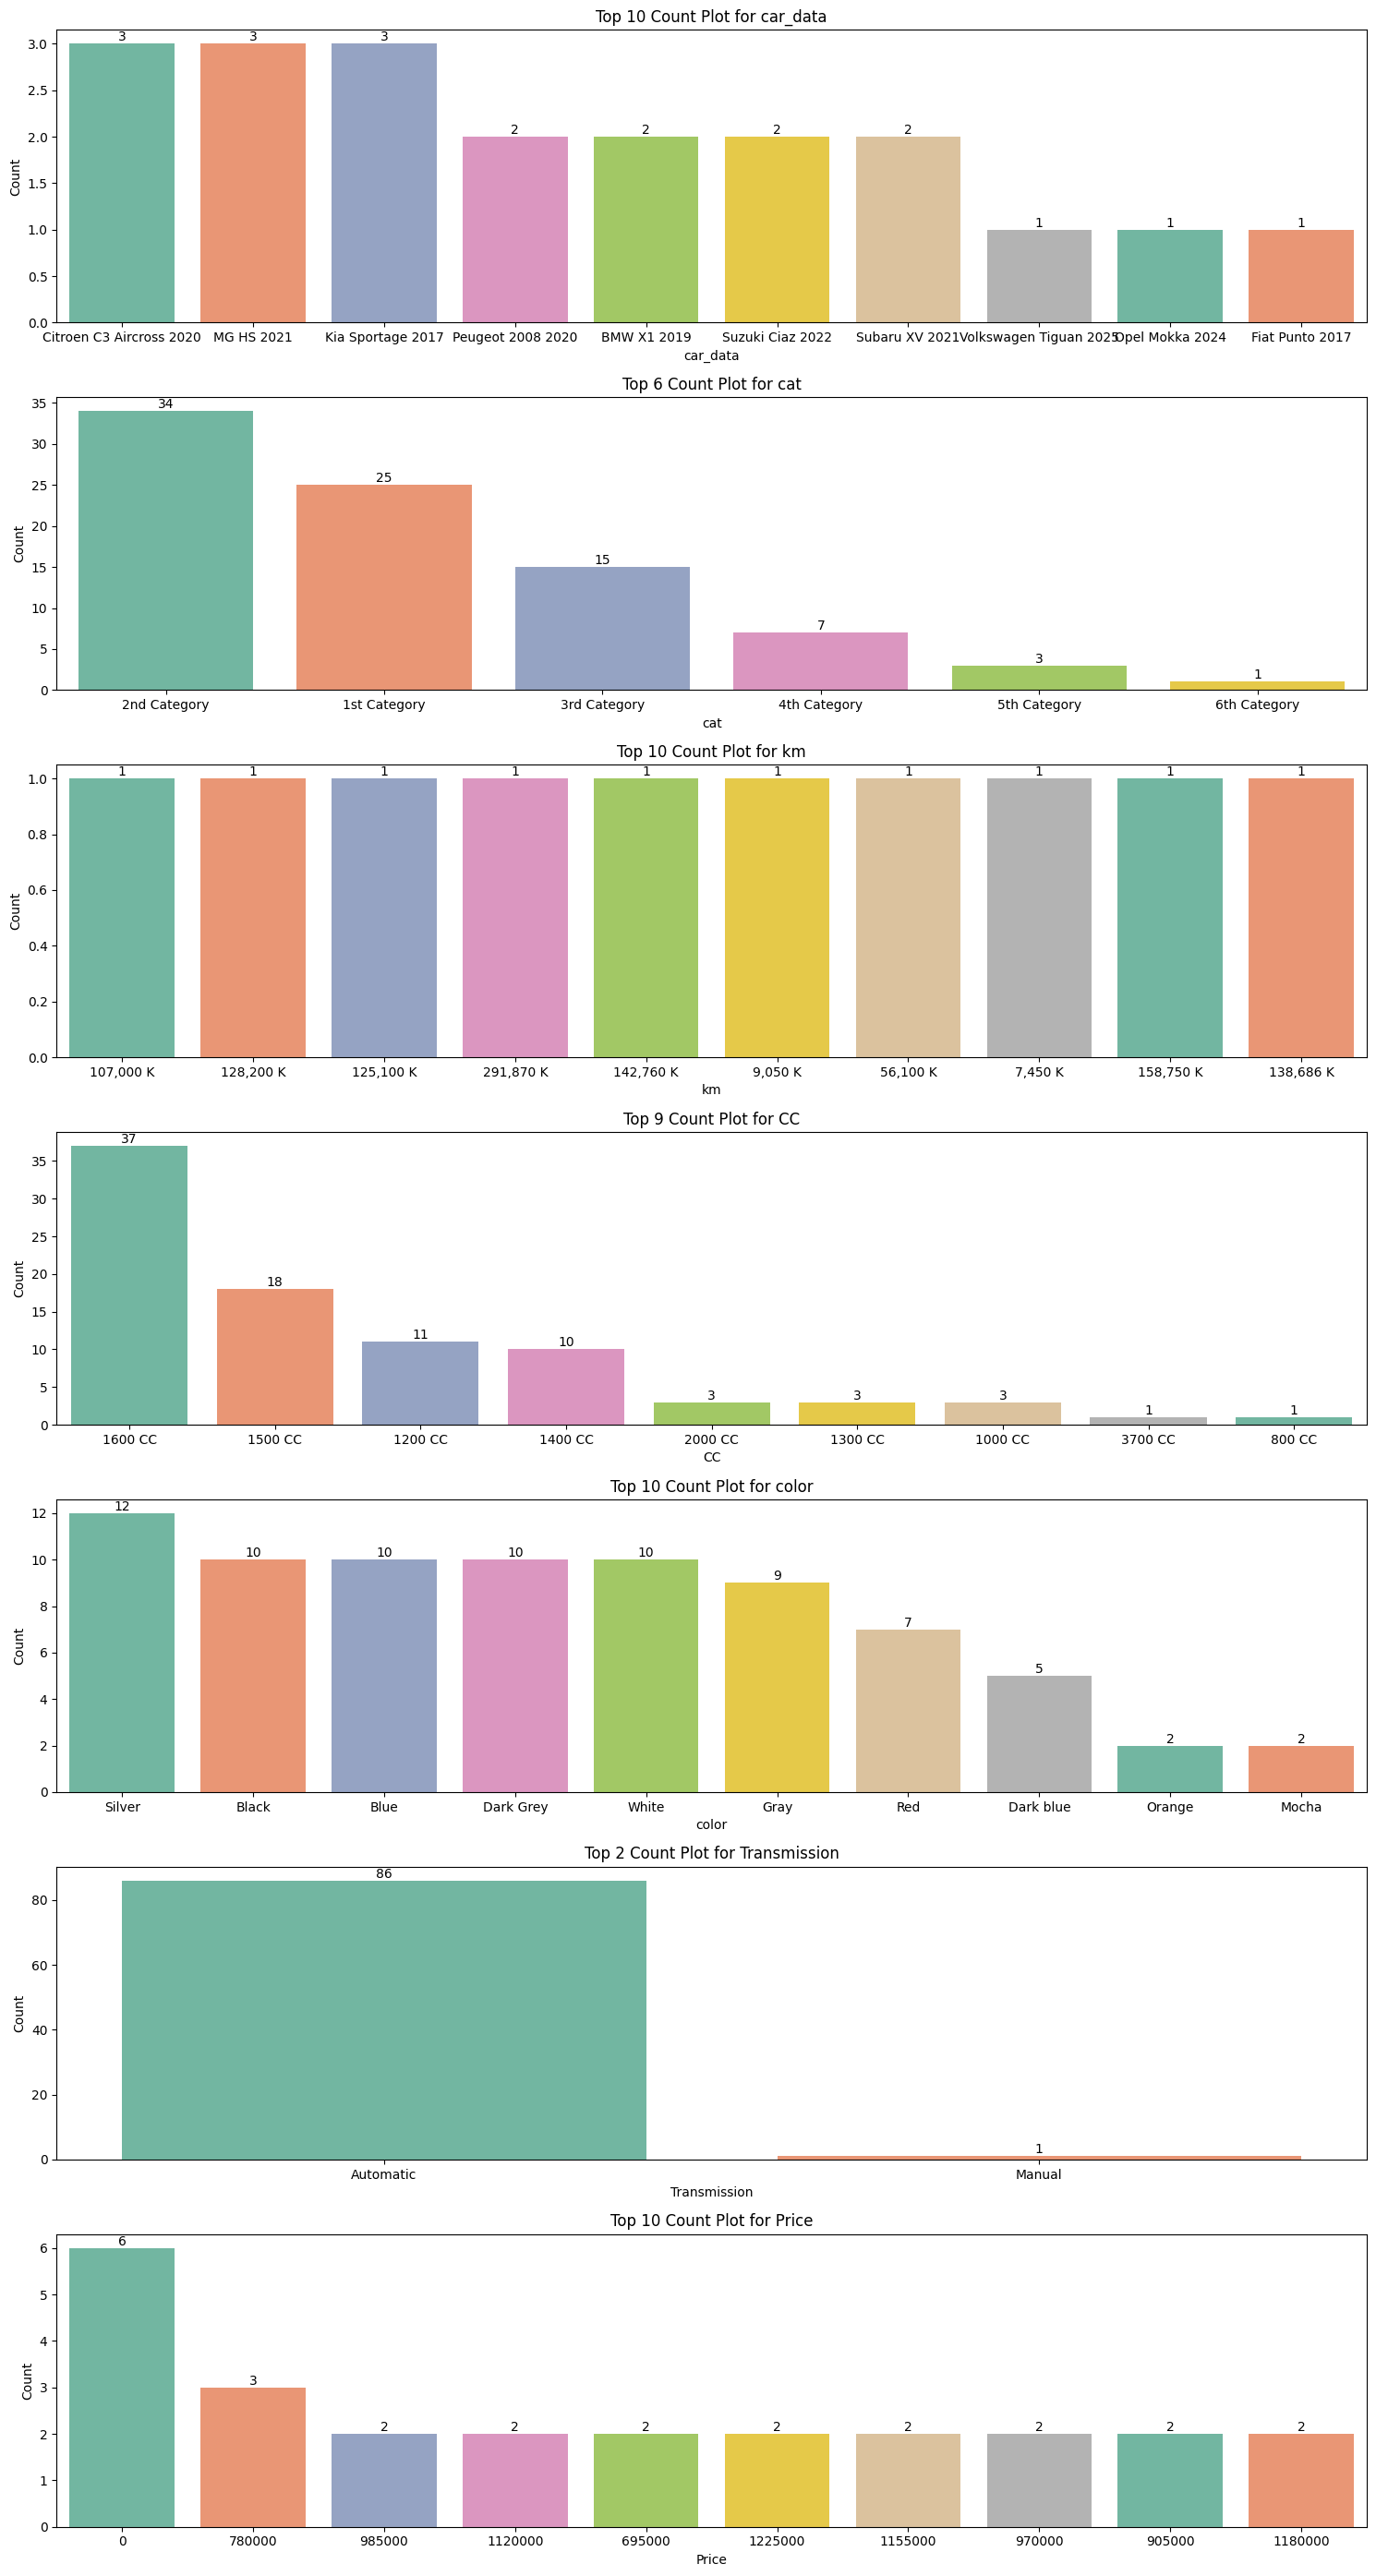

In [ ]:
visualize_top10(sylnder_cars, exclude_cols=['address','url','licence_valid'])

In [ ]:
sylnder_cars['km'].unique()

array(['107,000 K', '128,200 K', '125,100 K', '291,870 K', '142,760 K',
       '9,050 K', '56,100 K', '7,450 K', '158,750 K', '138,686 K',
       '98,250 K', '128,150 K', '78,700 K', '112,250 K', '108,250 K',
       '154,600 K', '117,450 K', '122,550 K', '75,150 K', '55,310 K',
       '150,160 K', '84,650 K', '154,800 K', '50,300 K', '116,350 K',
       '134,500 K', '105,500 K', '80,850 K', '93,355 K', '71,600 K',
       '142,050 K', '128,850 K', '25,200 K', '60,350 K', '45,100 K',
       '48,950 K', '180,400 K', '69,600 K', '88,200 K', '157,600 K',
       '68,650 K', '42,600 K', '92,950 K', '131,400 K', '62,300 K',
       '82,550 K', '56,150 K', '114,800 K', '104,750 K', '131,750 K',
       '69,900 K', '81,750 K', '87,800 K', '114,850 K', '35,200 K',
       '108,000 K', '103,400 K', '99,850 K', '166,050 K', '153,800 K',
       '94,700 K', '66,200 K', '113,050 K', '62,400 K', '87,600 K',
       '37,500 K', '57,000 K', '123,350 K', '95,950 K', '73,650 K',
       '46,200 K', '121,050 K',

In [58]:
sylnder_cars.cat.unique()

array(['2nd Category', '1st Category', '3rd Category', nan,
       '4th Category', '5th Category', '6th Category'], dtype=object)

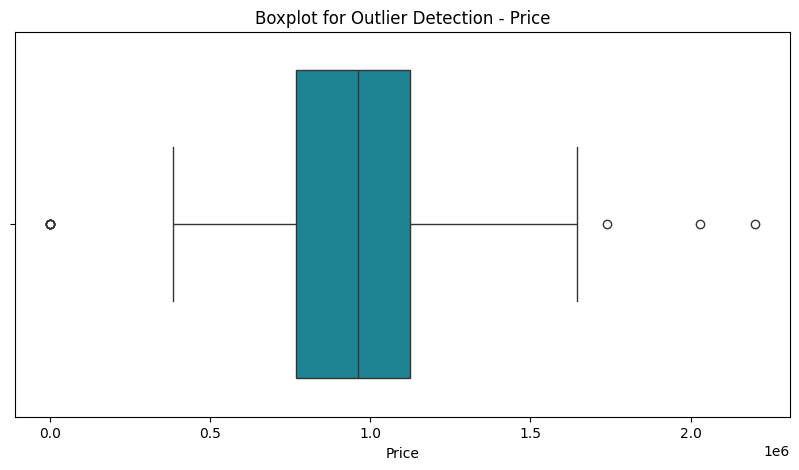

In [74]:
box_plot(sylnder_cars)

### Quality Issue 1:

In [ ]:
sylnder_cars['km'].value_counts()


km
107,000 K    1
128,200 K    1
125,100 K    1
291,870 K    1
142,760 K    1
            ..
94,800 K     1
42,900 K     1
74,750 K     1
24,050 K     1
53,800 K     1
Name: count, Length: 87, dtype: int64

* Issue and justification: **`km` column contains both the number and unit (should be numeric only)**

### Quality Issue 2:

In [ ]:
sylnder_cars['address'].value_counts()

address
Khamsin St. Extension, Zahraa El Maadi, infront of Herafyeen El gedida                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='address', data=sylnder_cars)
plt.xticks(rotation=90, ha='right', fontsize=4)
plt.title('Distribution of Cars by Address', fontsize=14)
plt.tight_layout()
plt.show()

**Issue and justification:**  
- The `address` column contains both the address and wrongly scraped comments (should be address only).
- Also address field contains full location details when only city might be needed.

###  Quality Issue 3:

In [59]:
sylnder_cars['licence_valid'].dtype

dtype('O')

Issue and justification:
- The `licence_valid` should be datetime not object.

###  Quality Issue 4:

In [78]:
sylnder_cars.Price.value_counts()

Price
0          6
780000     3
985000     2
1120000    2
695000     2
          ..
990000     1
1110000    1
900000     1
755000     1
845000     1
Name: count, Length: 70, dtype: int64

* Six sold cars listed at 0 EGP; the website did not display the actual sale price.


### Tidiness Issue 1:

In [35]:
sylnder_cars['car_data'].head()

0     Mercedes-Benz C180 2015
1    Citroen C3 Aircross 2020
2               BMW 520i 2019
3          Jeep Cherokee 2010
4             Fiat Punto 2017
Name: car_data, dtype: object

Issue and justification: **Multiple Variables in One Column (`car_data`)**

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [128]:
# Make copies of the datasets to ensure the raw dataframes 
# are not impacted
car_df_copy = car_df.copy()
sylnder_cars_copy = sylnder_cars.copy()

### **Quality Issue 1: FILL IN**

* **`km` column contains both the number and unit (should be numeric only)**

In [129]:
# FILL IN - Apply the cleaning strategy
sylnder_cars_copy['km'] = sylnder_cars_copy['km'].str.replace('K', '').str.replace(',', '').str.strip().astype(int)


In [130]:
# FILL IN - Validate the cleaning was successful
sylnder_cars_copy['km'].value_counts()

km
107000    1
128200    1
125100    1
291870    1
142760    1
         ..
94800     1
42900     1
74750     1
24050     1
53800     1
Name: count, Length: 87, dtype: int64

Justification: All `km` values are now numeric values.

### **Quality Issue 2: FILL IN**

- The `address` column contains both the address and wrongly scraped comments (should be address only).
- Also address field contains full location details when only city might be needed.

In [131]:
#FILL IN - Apply the cleaning strategy
# Replace the address for all observations to be Maadi

sylnder_cars_copy['address'] = 'Maadi'


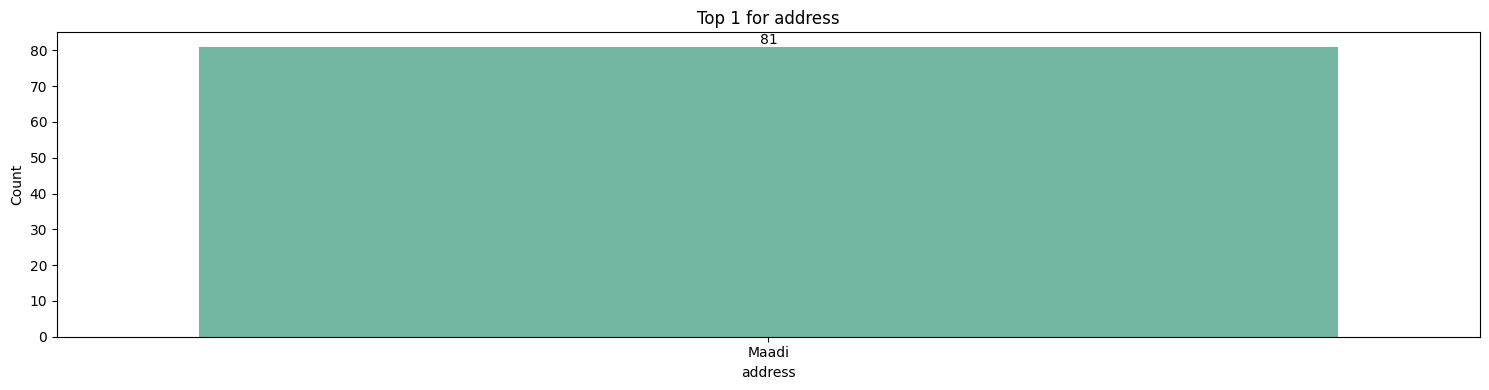

In [207]:
#FILL IN - Validate the cleaning was successful
visualize_top10(sylnder_cars_copy,only=['address'])

Justification: By using the `only` parameter, we can focus on specific columns for visualization, which is useful when we want to highlight certain aspects of the data. here we can visualize the top 10 values for the `address` column. And we can see that all address now are in the same city.

### **Quality Issue 3: FILL IN**

- The `licence_valid` should be datetime not object.

In [133]:
sylnder_cars_copy['licence_valid'] = pd.to_datetime(sylnder_cars_copy['licence_valid'], format='%m/%d/%Y', errors='coerce')


In [134]:
sylnder_cars_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   url            87 non-null     object        
 1   car_data       87 non-null     object        
 2   cat            85 non-null     object        
 3   km             87 non-null     int64         
 4   CC             87 non-null     object        
 5   color          87 non-null     object        
 6   Transmission   87 non-null     object        
 7   licence_valid  87 non-null     datetime64[ns]
 8   Price          87 non-null     int64         
 9   address        87 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 6.9+ KB


In [135]:
sylnder_cars_copy['licence_valid'].min() , sylnder_cars_copy['licence_valid'].max()

(Timestamp('2025-01-04 00:00:00'), Timestamp('2028-08-23 00:00:00'))

In [136]:
from datetime import date

# Assume sylnder_cars_copy is already defined as a DataFrame

# Convert today to pandas datetime
today = pd.to_datetime(date.today())

# Create flag based on comparison
sylnder_cars_copy['licence_valid_flag'] = (sylnder_cars_copy['licence_valid'] < today).astype(int)

# Count the values
valid_counts = sylnder_cars_copy['licence_valid_flag'].value_counts()
valid_counts


licence_valid_flag
0    76
1    11
Name: count, dtype: int64

* Data-quality flag: Sylnder listed vehicles whose registration had already expired.


### **Quality Issue 4: FILL IN**

* Six sold cars listed at 0 EGP; the website did not display the actual sale price.


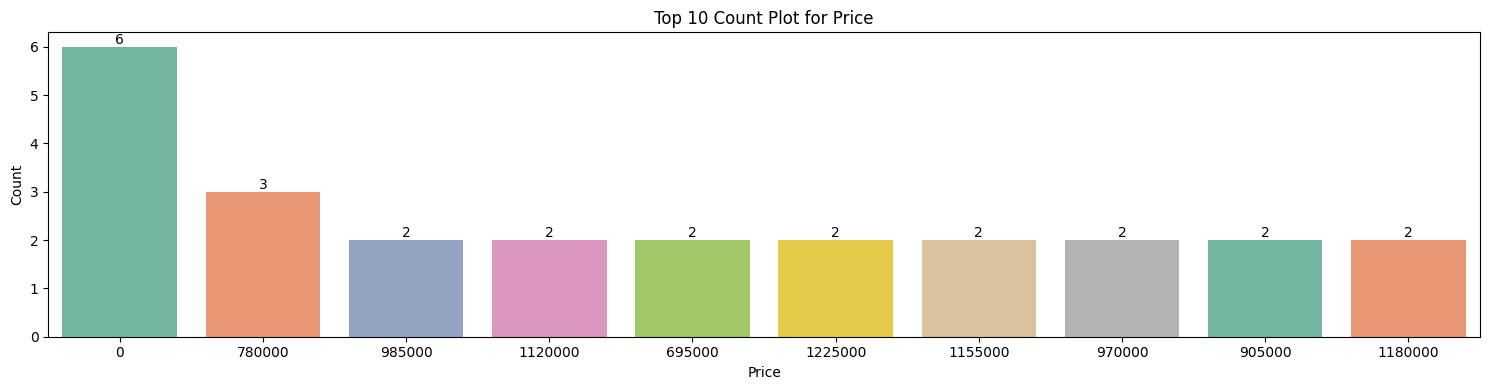

In [ ]:
visualize_top10(sylnder_cars_copy, only=['Price'])


In [138]:
sylnder_cars_copy['Price'].describe()

count    8.700000e+01
mean     9.458867e+05
std      4.014804e+05
min      0.000000e+00
25%      7.675000e+05
50%      9.600000e+05
75%      1.125000e+06
max      2.200000e+06
Name: Price, dtype: float64

In [139]:
sylnder_cars_copy = sylnder_cars_copy[sylnder_cars_copy['Price'] != 0.0]
sylnder_cars_copy['Price'].value_counts()


Price
780000     3
985000     2
1120000    2
695000     2
1225000    2
          ..
1330000    1
1110000    1
900000     1
755000     1
845000     1
Name: count, Length: 69, dtype: int64

In [140]:
sylnder_cars_copy.shape

(81, 11)

* Justified the removal of six records with a price of 0 EGP.

### **Tidiness Issue 1: FILL IN**

**Multiple Variables in One Column (`car_data`)**

In [141]:
#FILL IN - Apply the cleaning strategy
sylnder_cars_copy['car_data'].head()

0     Mercedes-Benz C180 2015
1    Citroen C3 Aircross 2020
2               BMW 520i 2019
3          Jeep Cherokee 2010
4             Fiat Punto 2017
Name: car_data, dtype: object

In [ ]:
# A new copy of the original DataFrame
sylnder_cars_copy2 = sylnder_cars_copy.copy()

In [150]:
sylnder_cars_copy2['Year'] = sylnder_cars_copy2['car_data'].str[-4:].astype(int)
sylnder_cars_copy2['car_data'] = sylnder_cars_copy2['car_data'].str[:-4].str.strip()
sylnder_cars_copy2[['Brand', 'Model']] = sylnder_cars_copy2['car_data'].str.split(' ', expand=True, n=1)
sylnder_cars_copy2.head()

,url,car_data,cat,km,CC,color,Transmission,licence_valid,Price,address,licence_valid_flag,Year,Brand,Model
0,https://sylndr.com/en/car-details/mercedesbenz...,Mercedes-Benz C180,2nd Category,107000,1600 CC,Blue,Automatic,2027-09-09,1645000,Maadi,0,2015,Mercedes-Benz,C180
1,https://sylndr.com/en/car-details/citroen/c3ai...,Citroen C3 Aircross,1st Category,128200,1200 CC,Orange,Automatic,2026-05-06,795000,Maadi,0,2020,Citroen,C3 Aircross
2,https://sylndr.com/en/car-details/bmw/520i/6e2...,BMW 520i,1st Category,125100,2000 CC,Black,Automatic,2027-03-27,2030000,Maadi,0,2019,BMW,520i
3,https://sylndr.com/en/car-details/jeep/cheroke...,Jeep Cherokee,1st Category,291870,3700 CC,Gray,Automatic,2028-02-09,780000,Maadi,0,2010,Jeep,Cherokee
4,https://sylndr.com/en/car-details/fiat/punto/a...,Fiat Punto,2nd Category,142760,1400 CC,Dark Blue,Automatic,2026-03-25,557140,Maadi,0,2017,Fiat,Punto


In [ ]:
#FILL IN - Validate the cleaning was successful
sylnder_cars_copy2.sample(5)

,url,car_data,cat,km,CC,color,Transmission,licence_valid,Price,address,licence_valid_flag,Year,Brand,Model
50,https://sylndr.com/en/car-details/fiat/tipo/3a...,Fiat Tipo,3rd Category,69900,1600 CC,Dark Grey,Automatic,2026-07-06,805000,Maadi,0,2021,Fiat,Tipo
18,https://sylndr.com/en/car-details/mg/5/bdd8be2...,MG 5,3rd Category,75150,1500 CC,Black,Automatic,2025-10-13,735000,Maadi,1,2022,MG,5
5,https://sylndr.com/en/car-details/opel/mokka/a...,Opel Mokka,2nd Category,9050,1200 CC,White,Automatic,2027-08-02,1225000,Maadi,0,2024,Opel,Mokka
24,https://sylndr.com/en/car-details/subaru/xv/65...,Subaru XV,1st Category,116350,1600 CC,White,Automatic,2025-09-07,1100000,Maadi,1,2020,Subaru,XV
47,https://sylndr.com/en/car-details/mitsubishi/e...,Mitsubishi Eclipse,2nd Category,114800,1500 CC,Black,Automatic,2026-05-03,905000,Maadi,0,2018,Mitsubishi,Eclipse


Justification: The dataset is now represented by new three clean, well-defined columns that accurately capture the required information.


### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [ ]:
#FILL IN - Remove unnecessary variables and combine datasets

In [174]:
# clean CC column
sylnder_cars_copy2['CC'] = sylnder_cars_copy2['CC'].str.replace('CC', '').str.strip()
sylnder_cars_copy2['CC'] = sylnder_cars_copy2['CC'].astype(int)
sylnder_cars_copy2.head()

,url,car_data,cat,km,CC,color,Transmission,licence_valid,Price,address,licence_valid_flag,Year,Brand,Model
0,https://sylndr.com/en/car-details/mercedesbenz...,Mercedes-Benz C180,2nd Category,107000,1600,Blue,Automatic,2027-09-09,1645000,Maadi,0,2015,Mercedes-Benz,C180
1,https://sylndr.com/en/car-details/citroen/c3ai...,Citroen C3 Aircross,1st Category,128200,1200,Orange,Automatic,2026-05-06,795000,Maadi,0,2020,Citroen,C3 Aircross
2,https://sylndr.com/en/car-details/bmw/520i/6e2...,BMW 520i,1st Category,125100,2000,Black,Automatic,2027-03-27,2030000,Maadi,0,2019,BMW,520i
3,https://sylndr.com/en/car-details/jeep/cheroke...,Jeep Cherokee,1st Category,291870,3700,Gray,Automatic,2028-02-09,780000,Maadi,0,2010,Jeep,Cherokee
4,https://sylndr.com/en/car-details/fiat/punto/a...,Fiat Punto,2nd Category,142760,1400,Dark Blue,Automatic,2026-03-25,557140,Maadi,0,2017,Fiat,Punto


In [175]:
# Reaname Mercedes-Benz to Mercedes
sylnder_cars_copy2['Brand'] = sylnder_cars_copy2['Brand'].str.replace('Mercedes-Benz', 'Mercedes')
sylnder_cars_copy2.head()

,url,car_data,cat,km,CC,color,Transmission,licence_valid,Price,address,licence_valid_flag,Year,Brand,Model
0,https://sylndr.com/en/car-details/mercedesbenz...,Mercedes-Benz C180,2nd Category,107000,1600,Blue,Automatic,2027-09-09,1645000,Maadi,0,2015,Mercedes,C180
1,https://sylndr.com/en/car-details/citroen/c3ai...,Citroen C3 Aircross,1st Category,128200,1200,Orange,Automatic,2026-05-06,795000,Maadi,0,2020,Citroen,C3 Aircross
2,https://sylndr.com/en/car-details/bmw/520i/6e2...,BMW 520i,1st Category,125100,2000,Black,Automatic,2027-03-27,2030000,Maadi,0,2019,BMW,520i
3,https://sylndr.com/en/car-details/jeep/cheroke...,Jeep Cherokee,1st Category,291870,3700,Gray,Automatic,2028-02-09,780000,Maadi,0,2010,Jeep,Cherokee
4,https://sylndr.com/en/car-details/fiat/punto/a...,Fiat Punto,2nd Category,142760,1400,Dark Blue,Automatic,2026-03-25,557140,Maadi,0,2017,Fiat,Punto


In [208]:
visualize_top10(sylnder_cars_copy2, only=['Brand'])

<Figure size 1500x0 with 0 Axes>

In [177]:
# lower columns names 
sylnder_cars_copy2.columns = sylnder_cars_copy2.columns.str.lower()
# keep the following columns: brand model year color km cc transmission city price
sylnder_cars_copy2 = sylnder_cars_copy2[['brand', 'model', 'year', 'color', 'km', 'cc', 'transmission', 'address', 'price']]
# rename address to city
sylnder_cars_copy2.rename(columns={'address': 'city'}, inplace=True)



In [180]:

sylnder_cars_copy2.sample(8)


,brand,model,year,color,km,cc,transmission,city,price
57,BMW,X1,2019,Black,99850,2000,Automatic,Maadi,1575000
7,Volkswagen,Tiguan,2025,Black,7450,1400,Automatic,Maadi,2200000
11,Renault,Kadjar,2019,Gray,128150,1200,Automatic,Maadi,865000
12,Renault,Megane,2023,Silver,78700,1300,Automatic,Maadi,930000
23,Suzuki,Alto,2019,Silver,50300,800,Manual,Maadi,385000
48,Hyundai,Tucson,2017,Dark Grey,104750,1600,Automatic,Maadi,1115000
49,BMW,X1,2017,Dark Grey,131750,1500,Automatic,Maadi,1155000
74,Renault,Kadjar,2022,Gray,58400,1200,Automatic,Maadi,990000


In [181]:
sylnder_cars_copy2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81 entries, 0 to 80
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         81 non-null     object
 1   model         81 non-null     object
 2   year          81 non-null     int64 
 3   color         81 non-null     object
 4   km            81 non-null     int64 
 5   cc            81 non-null     int64 
 6   transmission  81 non-null     object
 7   city          81 non-null     object
 8   price         81 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 6.3+ KB


In [183]:
# Keep the same columns for the other dataframe
car_df_copy.rename(columns={'Engine_CC': 'cc', 'Kilometers_Driven': 'km'}, inplace=True)
car_df_copy.columns = car_df_copy.columns.str.lower()
car_df_copy = car_df_copy[['brand', 'model', 'year', 'color', 'km', 'cc', 'transmission', 'city', 'price']]

In [184]:
car_df_copy.sample(7)

,brand,model,year,color,km,cc,transmission,city,price
4729,Mitsubishi,Pajero,2005,Gold,21000,3000,Automatic,El Haram,420000
2592,Kia,Carens,2010,Silver,165000,1600,Automatic,Sharqia,310000
4896,Fiat,128,1978,Yellow,66600,1100,Manual,6 October,15000
1898,Nissan,Qashqai,2017,Gray,98000,1200,Automatic,Tagamo3 - New Cairo,480000
283,Kia,Cerato,2014,Gray,183000,1600,Automatic,Cairo,395000
942,Jaguar,S-Type,2004,Cyan,119000,2500,Automatic,6 October,360000
6468,Kia,Cerato,2017,Silver,156000,1600,Automatic,Alexandria,385000


In [ ]:
# Merge the two dataframes
merged_df = pd.concat([sylnder_cars_copy2, car_df_copy], ignore_index=True)


In [186]:
merged_df.sample(15)

,brand,model,year,color,km,cc,transmission,city,price
6684,Daewoo,Lanos,2000,Silver,200000,1500,Manual,Sheikh Zayed City,117000
4064,Seat,Ateca,2020,White,40000,1500,Automatic,Damietta,870000
5546,Chevrolet,Optra,2018,Silver,64000,1500,Automatic,Beheira,270000
5903,Renault,Logan,2015,Silver,158000,1600,Manual,El Haram,168000
8329,Jac,S2,2016,Mocha,100000,1600,Automatic,Cairo,240000
5756,BMW,320,2008,Silver,220000,2000,Automatic,Heliopolis,390000
7528,MG,5,2022,Silver,9000,1500,Automatic,Sheikh Zayed City,450000
7014,Hyundai,Elantra MD,2016,Silver,79000,1600,Automatic,Cairo,440000
3955,Nissan,Juke,2012,Red,119000,1600,Automatic,Alexandria,270000
8583,MG,RX8,2020,Gray,60000,1600,Automatic,Heliopolis,630000


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [188]:
#FILL IN - saving data
merged_df.to_csv('merged_cars_data.csv', index=False)

In [189]:
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8912 entries, 0 to 8911
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         8912 non-null   object
 1   model         8912 non-null   object
 2   year          8912 non-null   int64 
 3   color         8912 non-null   object
 4   km            8912 non-null   int64 
 5   cc            8912 non-null   int64 
 6   transmission  8912 non-null   object
 7   city          8912 non-null   object
 8   price         8912 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 626.8+ KB


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* FILL IN from answer to Step 1

In [ ]:
# dominant_brand = merged_df['brand'].value_counts().idxmax()
# dominant_model = merged_df[merged_df['brand'] == dominant_brand]['model'].value_counts().idxmax()
# dominant_model


'Verna'

In [194]:
merged_df['model_brand'] = merged_df['brand']+ ' ' + merged_df['model']



In [196]:
merged_df['model_brand'].value_counts().nlargest(15)


model_brand
Nissan Sunny                  436
Toyota Corolla                359
Kia Cerato                    212
Renault Logan                 191
Fiat Tipo                     179
Mitsubishi Lancer EX Shark    171
Chevrolet Optra               169
Opel Astra                    162
Kia Sportage                  156
Byd F3                        138
Hyundai Verna                 136
Chevrolet Aveo                133
MG 5                          132
Mercedes C 180                120
Chevrolet Lanos               120
Name: count, dtype: int64

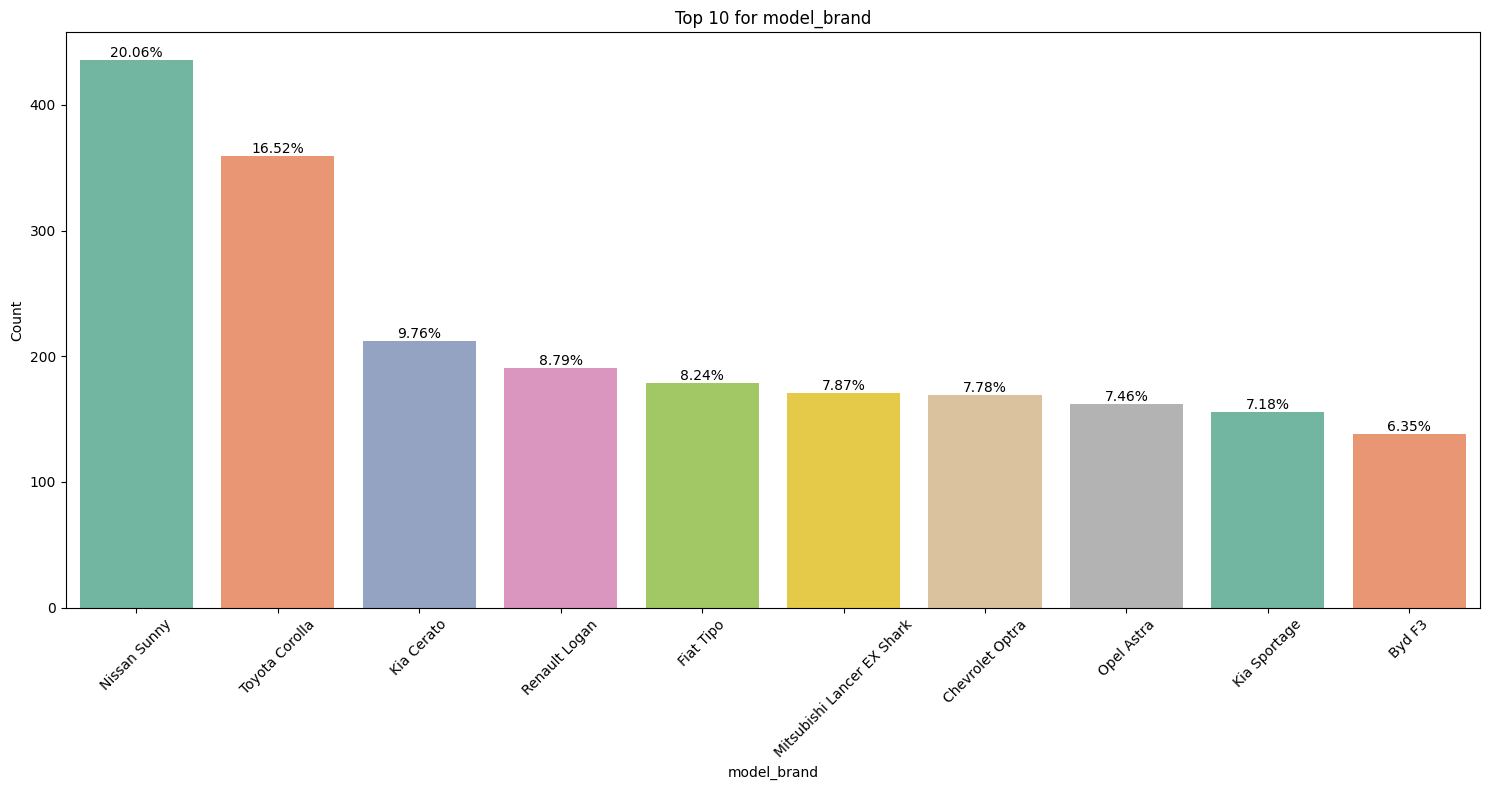

In [216]:
#Visualization 1 - Top-10 model_brand
visualize_top10(merged_df,only=['model_brand'], percentage=True)


### Answer to research question:
**`Nissan Sunny, Toyota Corolla, and Kia Cerato are the top models in Egypt, reflecting the strong presence of Asian manufacturers.`**


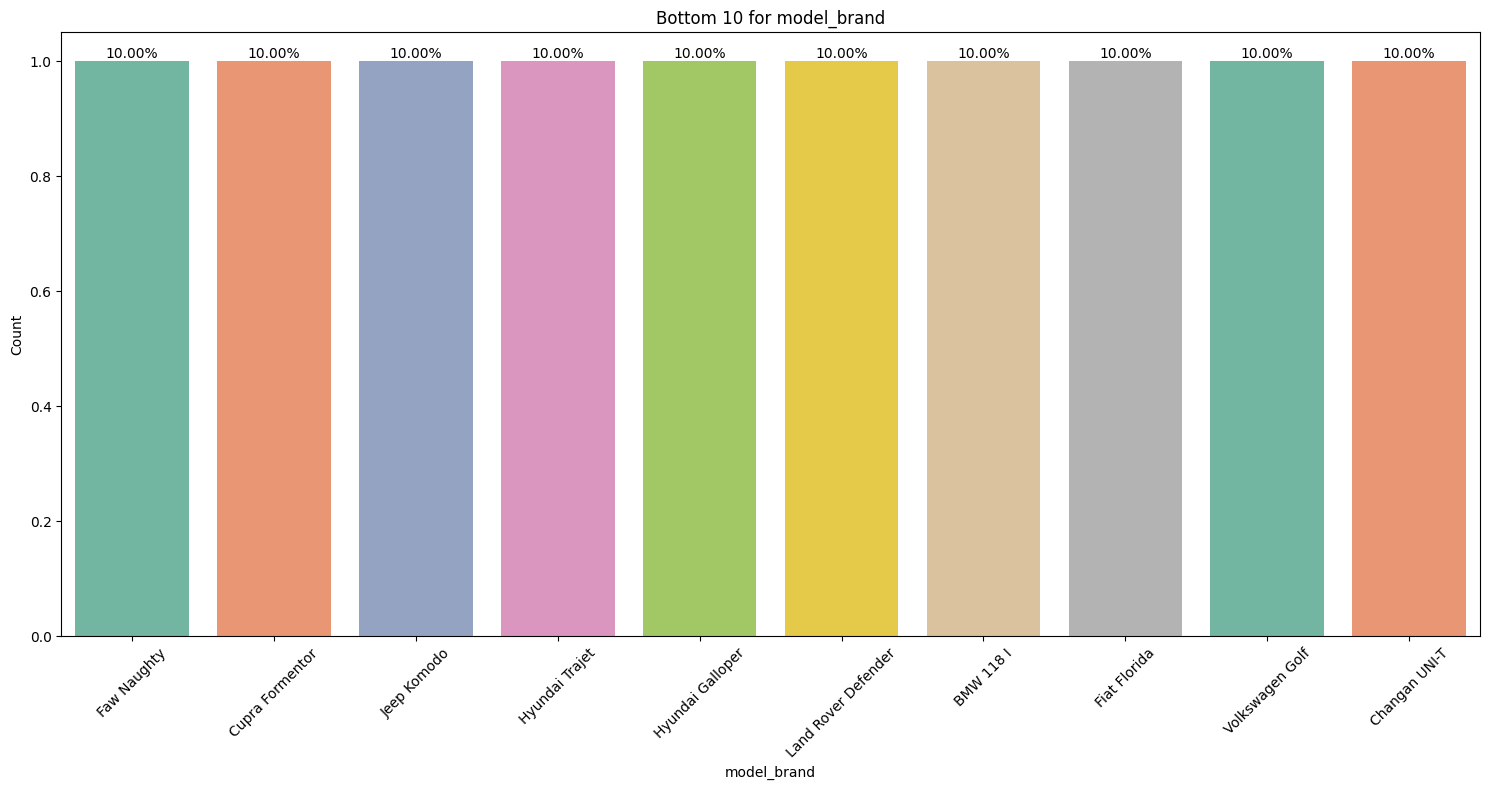

In [230]:
#Visualization 2 - Bottom-10 model_name
visualize_top10(merged_df,only=['model_brand'], percentage=True, top=False)

In [238]:
top_15_cities = merged_df.groupby(['city'])['price'].agg({'median','min','max'}).sort_values(by='median', ascending=False).head(15).reset_index()
top_15_cities

,city,min,max,median
0,Badr City,800000,800000,800000.0
1,Tala,45000,600000,600000.0
2,El Wadi El Gedid,580000,580000,580000.0
3,Menouf,280000,568000,568000.0
4,Tagamo3 - New Cairo,22000,3700000,550000.0
5,Zamalek,430000,2400000,550000.0
6,Dikirnis,380000,630000,542500.0
7,Abu Kabir,200000,530000,530000.0
8,Maadi,19000,2550000,500000.0
9,El Katameya,55000,2400000,500000.0


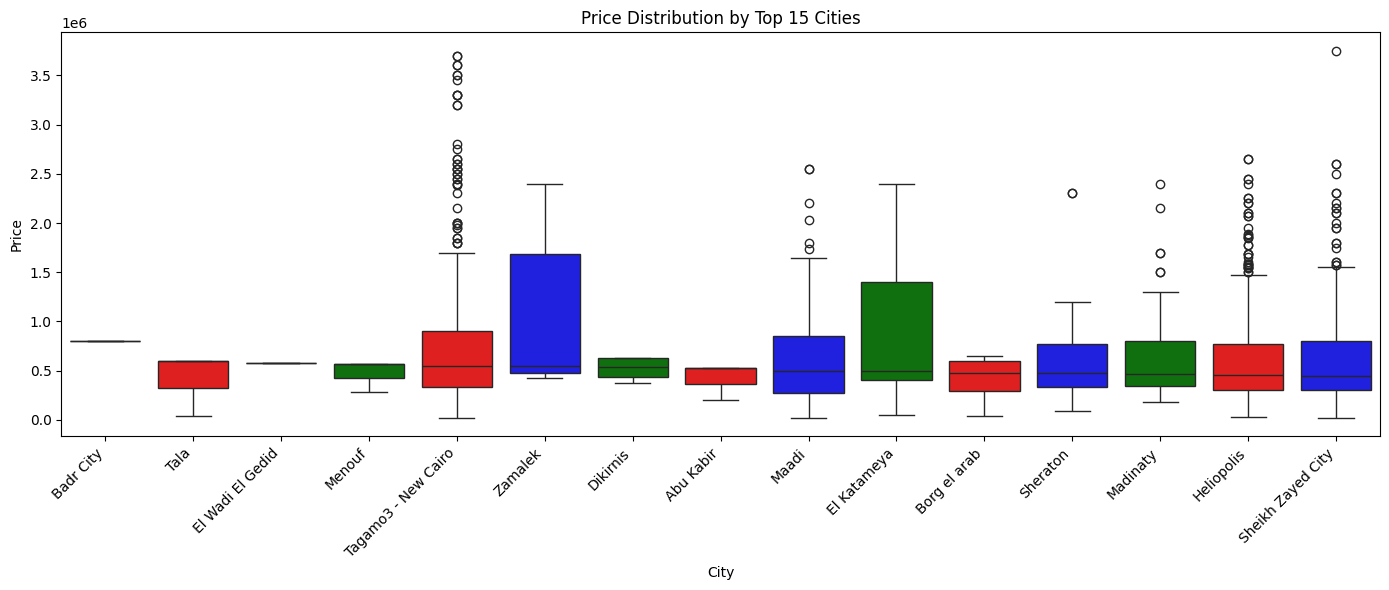

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



# Filter the original dataframe to only include the top 15 cities
top_cities_df = merged_df[merged_df['city'].isin(top_15_cities['city'])]
color = ['red' if x == 'max' else 'green' if x == 'min' else 'blue' for x in top_cities_df['price'].agg({'median','min','max'}).index]
# Draw a box plot for each city
plt.figure(figsize=(14, 6))
sns.boxplot(data=top_cities_df, x='city', y='price', order=top_15_cities['city'], palette=color)
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Top 15 Cities')
plt.xlabel('City')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


In [241]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.bar(
    top_cities_df.groupby('brand')['price'].median().reset_index(),
    x='brand',
    y='price',
    title='Average Used Car Price by Brand in Egypt',
    labels={'price': 'Median Price (EGP)', 'brand': 'Brand'},
    color='price',
    color_continuous_scale='Blues'
)

fig.update_layout(
    xaxis_tickangle=-45,
    template='plotly_white'
)

fig.show()


In [ ]:

# Luxury and expensive used cars where they bought (Model 2020 and byound).

new_model = merged_df[merged_df['year']>=2020]
new_model_citis = new_model.groupby(['city','model_brand','year'])['price'].max().nlargest(15).reset_index().sort_values(by='price',ascending=False)
fig = px.bar(
    new_model_citis,
    y='city',
    x='price',
    title='Max Used Car Price by City in Egypt',
    labels={'price': 'Max Price (EGP)', 'city': 'City'},
    color='model_brand',
    color_continuous_scale='Greens',
    # orientation='h'
)

fig.update_layout(
    xaxis_tickangle=-45,
    template='plotly_white'
)

fig.show()

### Answer to research question:
**`Tagamo3 - New Cairo records the highest maximum used-car price, with a total exceeding 20 million EGP.`**


In [275]:
merged_df.head()

,brand,model,year,color,km,cc,transmission,city,price,model_brand
0,Mercedes,C180,2015,Blue,107000,1600,Automatic,Maadi,1645000,Mercedes C180
1,Citroen,C3 Aircross,2020,Orange,128200,1200,Automatic,Maadi,795000,Citroen C3 Aircross
2,BMW,520i,2019,Black,125100,2000,Automatic,Maadi,2030000,BMW 520i
3,Jeep,Cherokee,2010,Gray,291870,3700,Automatic,Maadi,780000,Jeep Cherokee
4,Fiat,Punto,2017,Dark Blue,142760,1400,Automatic,Maadi,557140,Fiat Punto


In [ ]:
# convert from EGP to USD
merged_df['price_usd'] = merged_df['price'] / 50

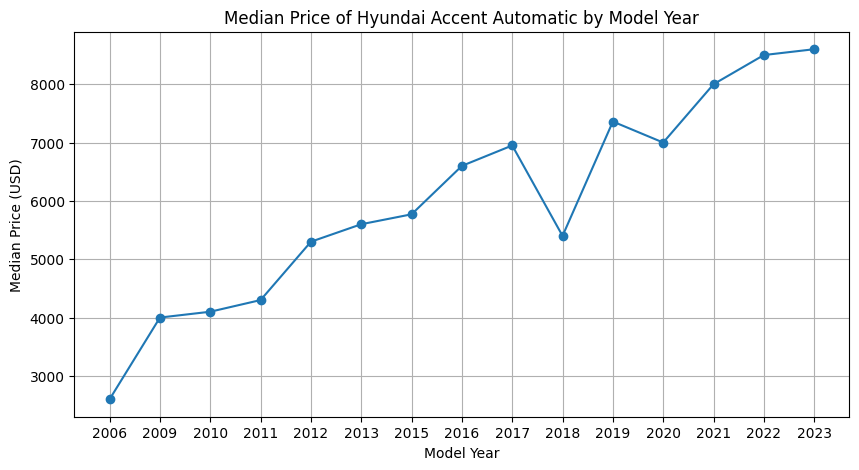

In [284]:
# Hyundai Accent Automatic model prices
hyundai_accent_auto = merged_df[(merged_df['model_brand'].str.contains('Hyundai')) & (merged_df['model'].str.contains('Accent')) & (merged_df['transmission'].str.contains('Automatic'))]
hyundai_accent_auto.year = hyundai_accent_auto.year.astype(str)
hyundai_accent_auto = hyundai_accent_auto.groupby(['year'])['price_usd'].median().reset_index()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(hyundai_accent_auto['year'], hyundai_accent_auto['price_usd'], marker='o')
plt.title('Median Price of Hyundai Accent Automatic by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Median Price (USD)')
plt.grid(True)
plt.show()


### Answer to reserch question: 
**`Although the primary dataset is two years old, prices have risen significantly over time; however, 2018 saw a temporary dip followed by a rebound. Further investigation is required to explain this pattern.`**


### **5.2:** Reflection
`Given more time, I would investigate each brand and each corresponding model to have more insights about them and go for collection of additional data. Additionally, I would delve deeper into research questions such as the correlation between car age and depreciation rate, and how regional factors within Egypt might influence used car prices.`
